# 🔍 Phase 02 — Exploratory Data Analysis (EDA)

**What is EDA?**  
Before building any model, we *look at the data* to understand it.
We ask questions like:
- Are fraud transactions bigger or smaller in amount?
- Do fraudsters strike more at night?
- Which card types are used more in fraud?

This phase produces **no model** — it just gives us insights we'll use later.

## 2.1 — Setup: Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned data we saved at the end of Phase 01
df = pd.read_csv('content/sample_data/df_preprocessed.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Fraud   : {df["isFraud"].sum():,} transactions ({df["isFraud"].mean()*100:.1f}%)')

Rows    : 590,540
Columns : 434
Fraud   : 20,663 transactions (3.5%)


## 2.2 — How Much Fraud Is There?

The dataset is **imbalanced** — most transactions are legitimate.  
This matters because a model that always says "legit" would be 96.5% accurate — but completely useless.  
That's why we'll use **AUC-ROC** and **F1-score** instead of accuracy.

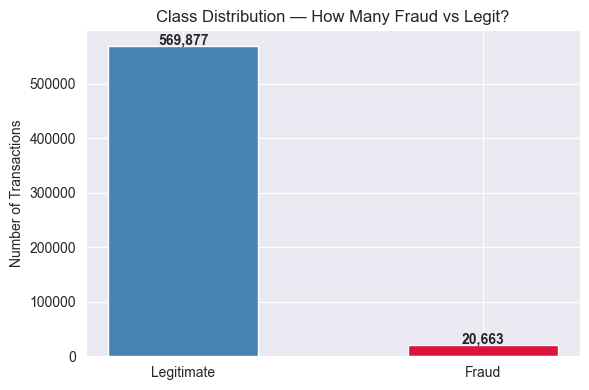

For every 1 fraud → there are 27 legitimate transactions


In [2]:
# Count how many legit vs fraud transactions we have
counts = df['isFraud'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Legitimate', 'Fraud'], counts.values,
        color=['steelblue', 'crimson'], width=0.5)
plt.title('Class Distribution — How Many Fraud vs Legit?')
plt.ylabel('Number of Transactions')

# Add count labels on top of bars
for i, v in enumerate(counts.values):
    plt.text(i, v + 3000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'For every 1 fraud → there are {int(counts[0]/counts[1])} legitimate transactions')

## 2.3 — Do Fraudsters Spend Differently?

**Question:** Are fraud transactions larger or smaller than normal ones?  
We'll compare the **distribution of transaction amounts** between fraud and legit.

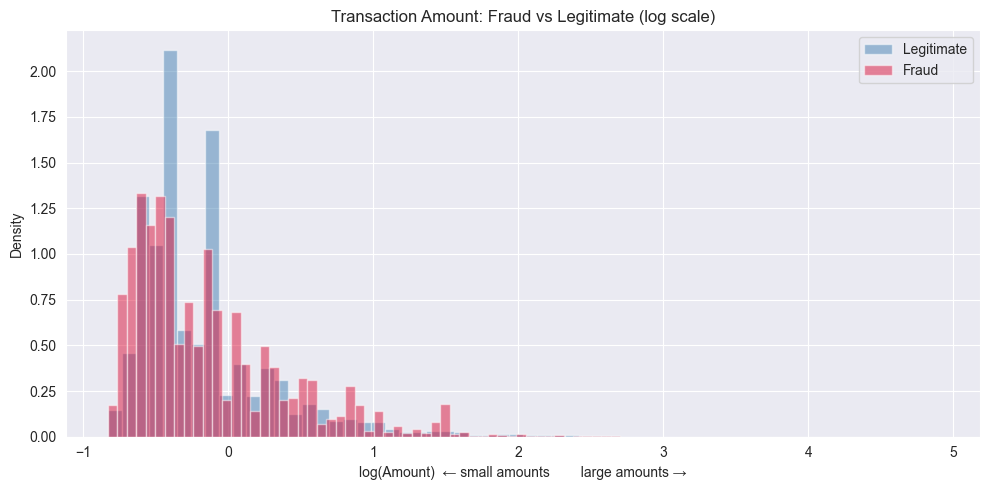

In [3]:
# Split data into fraud and legit groups
legit = df[df['isFraud'] == 0]['TransactionAmt']
fraud = df[df['isFraud'] == 1]['TransactionAmt']

plt.figure(figsize=(10, 5))

# We use log scale because a few huge transactions would squish everything else
plt.hist(np.log1p(legit), bins=60, alpha=0.5, color='steelblue',
         label='Legitimate', density=True)
plt.hist(np.log1p(fraud), bins=60, alpha=0.5, color='crimson',
         label='Fraud', density=True)

plt.title('Transaction Amount: Fraud vs Legitimate (log scale)')
plt.xlabel('log(Amount)  ← small amounts        large amounts →')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## 2.4 — When Does Fraud Happen?

`TransactionDT` is **seconds from a reference point** (not a real date).  
We can convert it to hours to see: *do fraudsters strike more at night?*

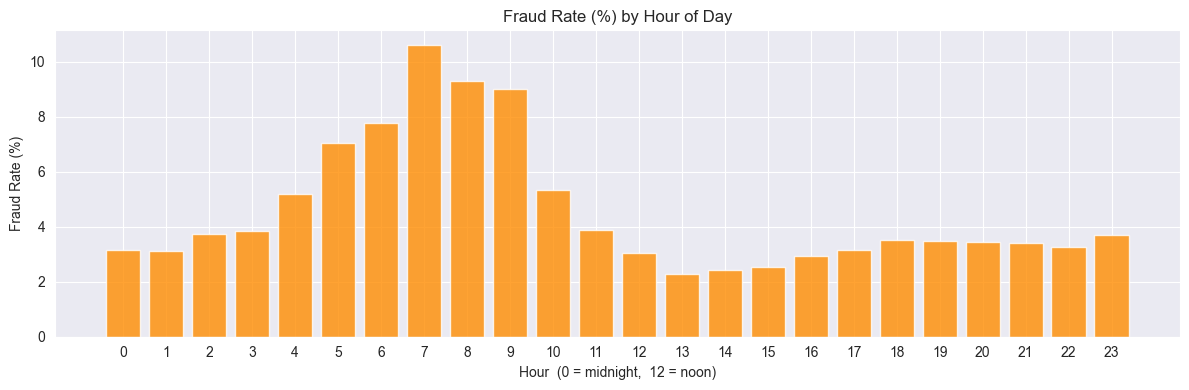

Fraud peaks at hour 7:00  (10.6% of transactions are fraud at this hour)


In [4]:
# Convert seconds → hour of day (0 = midnight, 12 = noon, 23 = 11pm)
df['hour'] = (df['TransactionDT'] % (3600 * 24)) // 3600

# For each hour, calculate what % of transactions are fraud
hourly = df.groupby('hour')['isFraud'].mean() * 100  # multiply by 100 for %

plt.figure(figsize=(12, 4))
plt.bar(hourly.index, hourly.values, color='darkorange', alpha=0.8)
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour  (0 = midnight,  12 = noon)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

peak = hourly.idxmax()
print(f'Fraud peaks at hour {peak}:00  ({hourly[peak]:.1f}% of transactions are fraud at this hour)')

## 2.5 — Which Card Types Are Used in Fraud?

**This is the most important plot for our GNN project.**  

If some card types are used in fraud more than others, it means these categories **carry real signal**.  
In Phase 03, these card columns will become **nodes in our graph**.

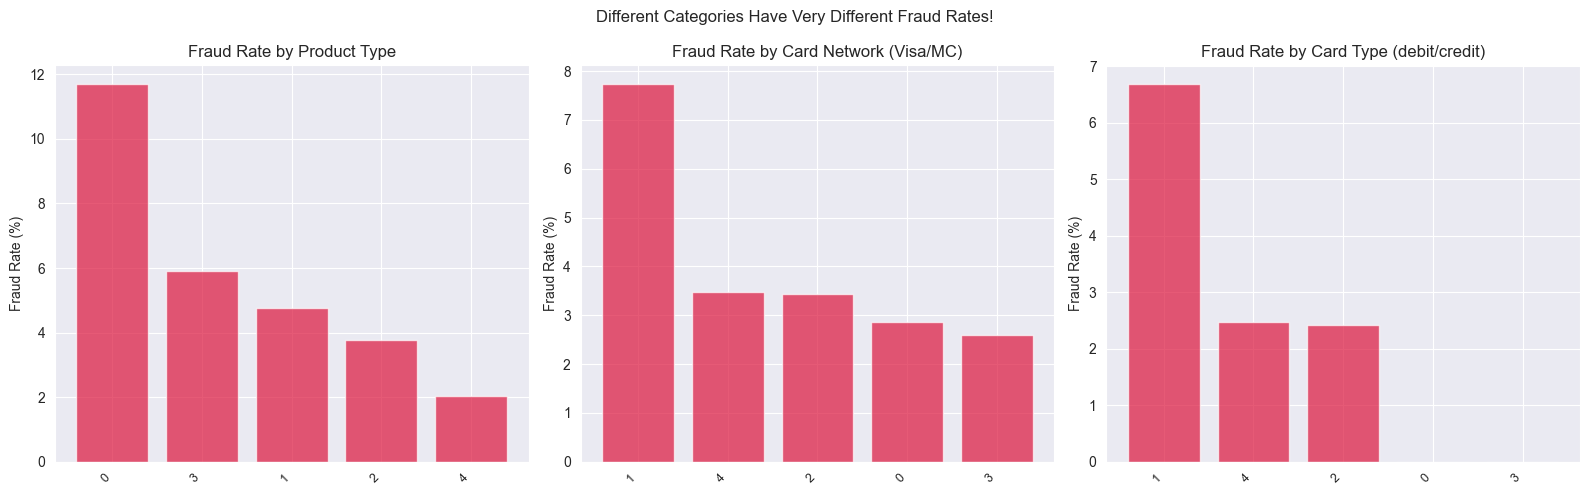

✅ High variance across categories = these columns are useful graph nodes


In [5]:
# We'll look at fraud rate for 3 key entity columns
# (These will later become graph nodes in Phase 03)
entity_cols = {
    'ProductCD'    : 'Product Type',
    'card4'        : 'Card Network (Visa/MC)',
    'card6'        : 'Card Type (debit/credit)',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title) in zip(axes, entity_cols.items()):
    # For each unique value in this column: calculate fraud rate
    stats = df.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100

    ax.bar(range(len(stats)), stats.values, color='crimson', alpha=0.7)
    ax.set_xticks(range(len(stats)))
    ax.set_xticklabels(stats.index.astype(str), rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Fraud Rate by {title}')
    ax.set_ylabel('Fraud Rate (%)')

plt.suptitle('Different Categories Have Very Different Fraud Rates!', fontsize=12)
plt.tight_layout()
plt.show()

print('✅ High variance across categories = these columns are useful graph nodes')

# 2.6 — Email Domain Fraud Rate


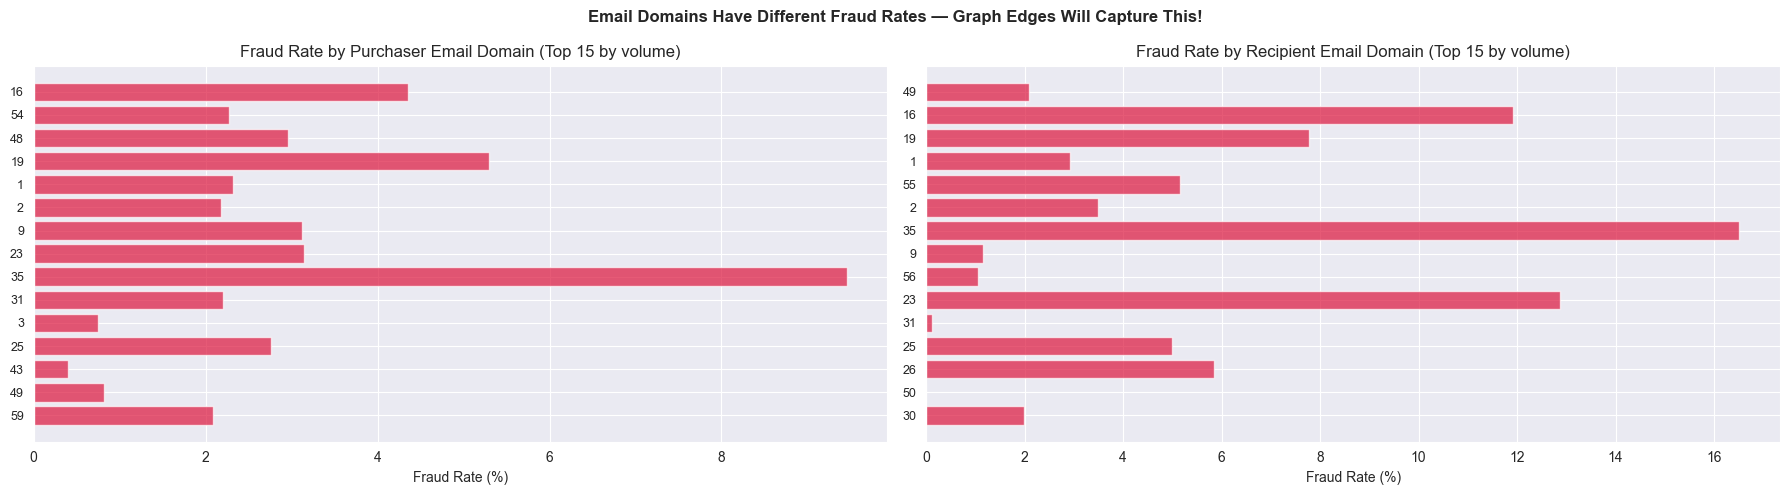

✅ Email domains are strong candidates for graph nodes in Phase 03


In [6]:
## 2.7 — Which Email Domains Are Riskiest?
# Email domains are important entity nodes in our future graph.
# If gmail users have different fraud rates than hotmail users,
# the graph edges connecting transactions via email will carry real signal.

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, col, title in zip(axes,
                           ['P_emaildomain', 'R_emaildomain'],
                           ['Purchaser Email Domain', 'Recipient Email Domain']):
    # Calculate fraud rate per domain, keep top 15 by volume
    domain_stats = df.groupby(col).agg(
        fraud_rate=('isFraud', 'mean'),
        count=('isFraud', 'count')
    ).sort_values('count', ascending=False).head(15)

    domain_stats['fraud_rate'] = domain_stats['fraud_rate'] * 100

    bars = ax.barh(range(len(domain_stats)), domain_stats['fraud_rate'],
                   color='crimson', alpha=0.7)
    ax.set_yticks(range(len(domain_stats)))
    ax.set_yticklabels(domain_stats.index.astype(str), fontsize=9)
    ax.set_xlabel('Fraud Rate (%)')
    ax.set_title(f'Fraud Rate by {title} (Top 15 by volume)')
    ax.invert_yaxis()

plt.suptitle('Email Domains Have Different Fraud Rates — Graph Edges Will Capture This!',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ Email domains are strong candidates for graph nodes in Phase 03')

## 2.7 — Which V-Features Correlate With Fraud?

The dataset has **339 V-features** (Vesta bank's internal engineered features).  
We don't know what they mean — but we can find which ones are **most correlated** with fraud.  

We'll keep only the **top 40** most correlated ones as node features in the GNN.  
This reduces noise and speeds up training.

Total V-features: 339


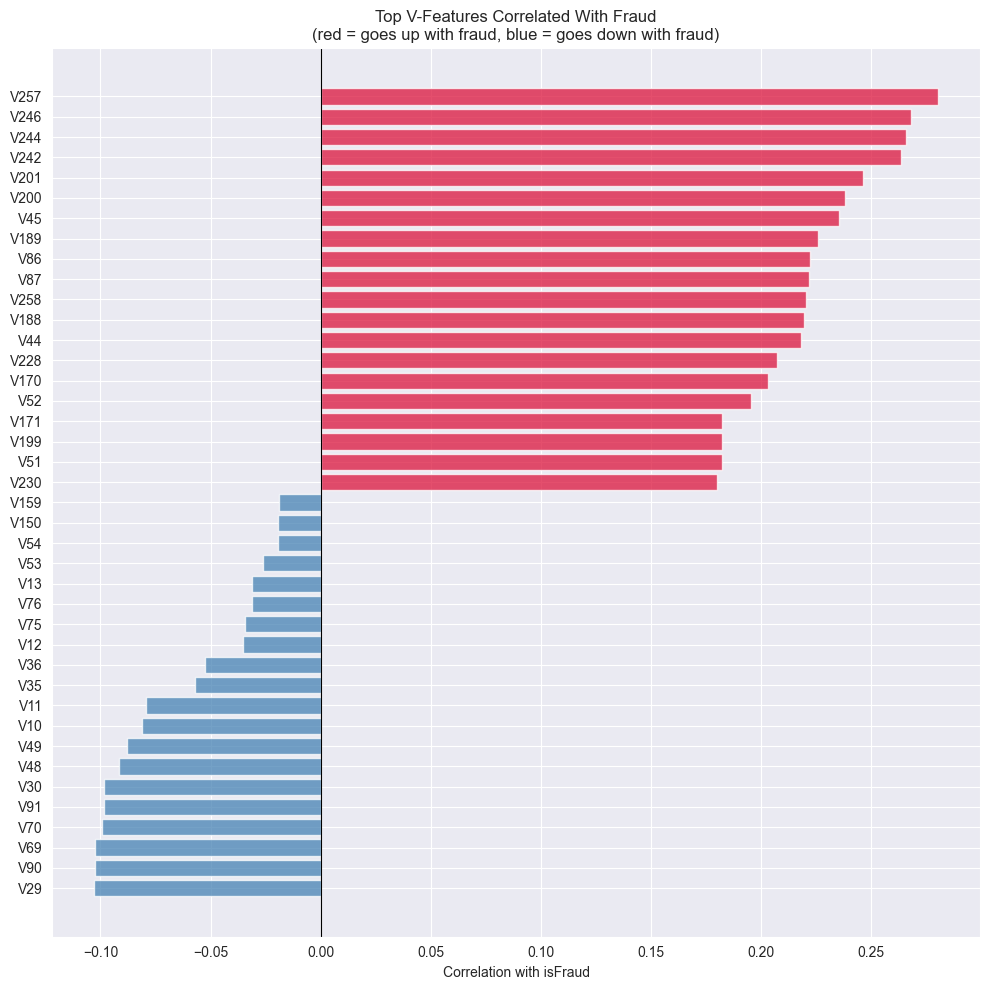


We will use these 40 V-features in the GNN:
['V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V45', 'V189', 'V86', 'V87'] ... and 30 more


In [7]:
import json
# Get all V-feature column names
v_cols = [c for c in df.columns if c.startswith('V')]
print(f'Total V-features: {len(v_cols)}')

# Calculate Pearson correlation of each V-feature with isFraud
# Positive = feature goes up when fraud goes up
# Negative = feature goes down when fraud goes up
corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')

# Get top 20 most positive and top 20 most negative correlations
top_corr = pd.concat([corr.nlargest(20), corr.nsmallest(20)]).sort_values()

plt.figure(figsize=(10, 10))
colors = ['crimson' if v > 0 else 'steelblue' for v in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors, alpha=0.75)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top V-Features Correlated With Fraud\n(red = goes up with fraud, blue = goes down with fraud)')
plt.xlabel('Correlation with isFraud')
plt.tight_layout()
plt.show()

# Save which V-features we'll actually use in the GNN (Phase 03)
useful_v_features = corr.abs().nlargest(40).index.tolist()
with open('content/sample_data/useful_v_features.json', 'w') as f:
    json.dump(useful_v_features, f)
print(f'\nWe will use these {len(useful_v_features)} V-features in the GNN:')
print(useful_v_features[:10], '... and 30 more')